# **Rule Based**

In [ ]:
video_folder_test = ("/content/drive/MyDrive/SP2_Child_Dataset_Video/test")
video_folder_val = ("/content/drive/MyDrive/SP2_Child_Dataset_Video/val")
test_labels_file = ("/content/drive/MyDrive/SP2_Child_Dataset_Video/True_ResultTest.csv")
val_labels_file = ("/content/drive/MyDrive/SP2_Child_Dataset_Video/True_ResultTest.csv")
model_path = Path("/content/best.pt")
model = YOLO(model_path)

In [ ]:
DIST_THRESHOLD = 180        # Distance threshold used to match detections with previous tracked positions
ALONE_THRESHOLD = 3.0       # Time (in seconds) a child must stay alone before triggering alert
ADULT_CONFIRM_TIME = 3.0    # Time (in seconds) adult must be visible to reset alone counter
ADULT_CONF_THRESHOLD = 0.7  # Confidence threshold for adult detection (higher for reliability)
CHILD_CONF_THRESHOLD = 0.5  # Confidence threshold for child detection

In [ ]:
ML_FEATURES = []            # Global list to store ML feature vectors (one per video)
TOTAL_ALONE_TIME = 0        # Total accumulated time the child has been alone across the entire video (for ML feature)
MAX_ALONE_TIME = 0          # Longest continuous duration the child stayed alone (captures worst-case scenario)
ADULT_FRAME_COUNT = 0       # Number of frames where at least one reliable adult is detected (used for ratio feature)
TOTAL_FRAMES = 0            # Total number of processed frames in the video (used for normalization)
ALONE_START_TIME = None     # Timestamp when the child first becomes alone (used to measure duration segments)
ADULT_APPEARANCE_START = None  # Timestamp when an adult starts being consistently detected

In [ ]:
# Calculate Euclidean distance between two 2D points.
def euclidean(p1, p2):
    return math.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)

In [ ]:
def analyze_video(video_path, model, conf_threshold=0.3, show=True):
    cap = cv2.VideoCapture(str(video_path))

    names = model.names

    # ---------------- STATE VARIABLES ----------------
    alone_start_time = None         # Timestamp when child started being alone
    adult_appearance_start = None   # Timestamp when dult started appearing
    alert_triggered = False

    # ---------------- TRACKING DICTIONARIES ----------------
    id_last_position = {}   # Stores last known position of each unified ID
    byteID_to_unified = {}  # Maps YOLO tracker ID to our custom unified ID
    next_unified_id = 1     # Counter to generate new unified IDs

    # ---------------- ML FEATURE VARIABLES (ADD-ONLY) ----------------
    total_alone_time = 0
    max_alone_time = 0
    adult_frame_count = 0
    total_frames = 0

    while True:
        # Read a single frame from the video
        ret, frame = cap.read()
        # Stop if no more frames are available
        if not ret:
            break

        timestamp = time.time()  # Record current time

        # count frames
        total_frames += 1

        # Run YOLO tracking on current frame
        results = model.track(source=frame,
            conf=conf_threshold,
            persist=True,
            stream=False,
            verbose=False,
            tracker="bytetrack.yaml"
        )

        current_children_ids = []
        current_adults_ids = []
        max_child_conf = 0

        for r in results:
            if r.boxes is None: continue

            # Extract labels, confidence scores, bounding boxes, and tracker IDs
            labels = [model.names[int(c)] for c in r.boxes.cls]
            confs = r.boxes.conf
            boxes = r.boxes.xyxy
            ids = r.boxes.id if r.boxes.id is not None else [None]*len(labels)

            for label, box, conf_score, byte_id in zip(labels, boxes, confs, ids):
                conf_val = float(conf_score)

                # Bounding box coordinates
                x1, y1, x2, y2 = map(int, box)

                # Compute center of bounding box
                cx, cy = (x1 + x2) / 2, (y1 + y2) / 2

                if byte_id is not None:
                    # If this YOLO ID was never seen before
                    if byte_id not in byteID_to_unified:
                        matched_id = None

                        # Try matching with previous unified IDs
                        for uid, last_pos in id_last_position.items():
                            if euclidean((cx, cy), last_pos) < DIST_THRESHOLD:
                                matched_id = uid
                                break

                        # If no match found, create new unified ID
                        if matched_id is None:
                            matched_id = next_unified_id
                            next_unified_id += 1

                        byteID_to_unified[byte_id] = matched_id

                    unified_id = byteID_to_unified[byte_id]
                    id_last_position[unified_id] = (cx, cy)
                else:
                    continue  # Ignore detection if no tracking ID

                if label == "child" and conf_val >= CHILD_CONF_THRESHOLD:
                    current_children_ids.append(unified_id)
                    max_child_conf = max(max_child_conf, conf_val)
                    #BGR
                    color = (0, 0, 255)

                elif label == "adult" and conf_score >= ADULT_CONF_THRESHOLD:
                    current_adults_ids.append(unified_id)
                    color = (255, 0, 0)

                else:
                    continue

                if show:
                    label_str = f"ID:{unified_id} {label} {conf_val:.2f}"
                    cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
                    cv2.putText(frame, label_str, (x1, y1 - 10),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

        has_child = len(current_children_ids) > 0
        has_reliable_adult = len(current_adults_ids) > 0

        # adult presence tracking
        if has_reliable_adult:
            adult_frame_count += 1

        if has_child:
            if has_reliable_adult:
                # Start counting adult presence duration
                if adult_appearance_start is None:
                    adult_appearance_start = timestamp

                # If adult confirmed for enough time, reset alone counter
                if (timestamp - adult_appearance_start) >= ADULT_CONFIRM_TIME:

                    # accumulate total alone time
                    if alone_start_time is not None:
                        total_alone_time += (timestamp - alone_start_time)

                    alone_start_time = None

            else:
                # No reliable adult detected
                adult_appearance_start = None

                if alone_start_time is None:
                    alone_start_time = timestamp

                elapsed_alone = timestamp - alone_start_time

                # track max alone duration
                max_alone_time = max(max_alone_time, elapsed_alone)

                # Trigger alert if child alone for too long
                if elapsed_alone >= ALONE_THRESHOLD:
                    alert_triggered = True
                    cv2.putText(frame, f"ALERT: CHILD ALONE! ({elapsed_alone:.1f}s)", (50,50),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 2)

        else:
            alone_start_time = None
            adult_appearance_start = None


    # handle last segment
    if alone_start_time is not None:
        total_alone_time += (timestamp - alone_start_time)

    # save ONE row per video (ML ready)
    ML_FEATURES.append({
        "video": os.path.basename(video_path),
        "num_children": len(current_children_ids),
        "num_adults": len(current_adults_ids),
        "max_alone_time": max_alone_time,
        "total_alone_time": total_alone_time,
        "adult_presence_ratio": adult_frame_count / max(total_frames, 1)
    })

    print(f"Video: {os.path.basename(video_path)} | ALERT: {alert_triggered}")

    return {"video": os.path.basename(video_path), "alert": alert_triggered}

In [ ]:
def process_videos(video_folder, model, conf):
    videos = [f for f in os.listdir(video_folder)
              if f.lower().endswith((".mp4"))]
    results_list = []

    for file_name in videos:
        video_path = video_folder / file_name
        result = analyze_video(video_path, model, conf_threshold=conf, show=True)
        results_list.append(result)

    return results_list

In [ ]:
results_test = process_videos(Path(video_folder_test), model,0.3)
results_val = process_videos(Path(video_folder_val), model,0.3)

Video: child-36.mp4 | ALERT: True
Video: family-10.mp4 | ALERT: False
Video: family-19.mp4 | ALERT: False
Video: family-27.mp4 | ALERT: False
Video: child-37.mp4 | ALERT: True
Video: family-14.mp4 | ALERT: False
Video: child-42.mp4 | ALERT: True
Video: child-29.mp4 | ALERT: True
Video: adult-3.mp4 | ALERT: False
Video: child-30.mp4 | ALERT: True
Video: family-2.mp4 | ALERT: False
Video: child-31.mp4 | ALERT: True
Video: adult-4.mp4 | ALERT: False
Video: adult-7.mp4 | ALERT: False
Video: child-33.mp4 | ALERT: True
Video: child-26.mp4 | ALERT: True
Video: child-38.mp4 | ALERT: True
Video: child-22.mp4 | ALERT: False
Video: family-28.mp4 | ALERT: False
Video: family-29.mp4 | ALERT: True
Video: child-43.mp4 | ALERT: False
Video: family-39.mp4 | ALERT: False
Video: family-12.mp4 | ALERT: False
Video: child-47.mp4 | ALERT: True
Video: family-24.mp4 | ALERT: False
Video: family-25.mp4 | ALERT: False
Video: family-6.mp4 | ALERT: False


In [ ]:
ml_df = pd.DataFrame(ML_FEATURES)

save_path = "/content/drive/MyDrive/SP2_Child_Dataset_Video/ml_features.csv"

ml_df.to_csv(save_path, index=False)

print("ML features saved to:", save_path)

ML features saved to: /content/drive/MyDrive/SP2_Child_Dataset_Video/ml_features.csv


In [ ]:
true_df = pd.read_csv(val_labels_file)
true_dict = dict(zip(true_df['video_name'], true_df['Alert']))

y_true_val = []
y_pred_val = []

for r in results_val:
    video_name = r["video"]
    y_pred_val.append(int(r["alert"]))
    y_true_val.append(true_dict.get(video_name, 0))


acc = accuracy_score(y_true_val, y_pred_val)
prec = precision_score(y_true_val, y_pred_val)
rec = recall_score(y_true_val, y_pred_val)

print("\n--- Metrics ---")
print(f"Accuracy: {acc*100:.2f}%")
print(f"Precision: {prec*100:.2f}%")
print(f"Recall: {rec*100:.2f}%")


--- Metrics ---
Accuracy: 66.67%
Precision: 0.00%
Recall: 0.00%


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


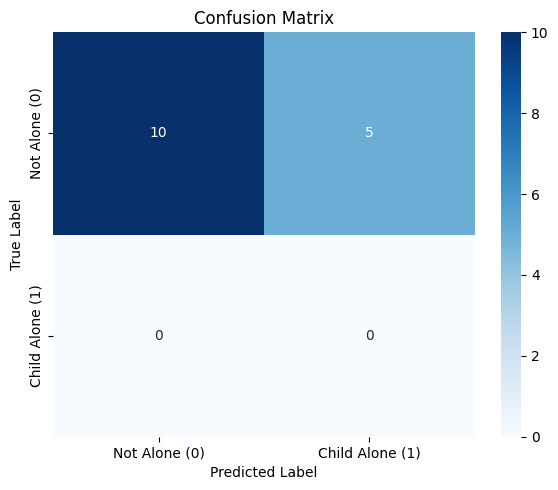

In [ ]:
cm = confusion_matrix(y_true_val, y_pred_val)  # [[TN, FP],[FN, TP]]
labels = ["Not Alone (0)", "Child Alone (1)"]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()

In [ ]:
true_df = pd.read_csv(test_labels_file)
true_dict = dict(zip(true_df['video_name'], true_df['Alert']))

y_true = []
y_pred = []

for r in results_test:
    video_name = r["video"]
    y_pred.append(int(r["alert"]))
    y_true.append(true_dict.get(video_name, 0))


acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)

print("\n--- Metrics ---")
print(f"Accuracy: {acc*100:.2f}%")
print(f"Precision: {prec*100:.2f}%")
print(f"Recall: {rec*100:.2f}%")



--- Metrics ---
Accuracy: 100.00%
Precision: 100.00%
Recall: 100.00%


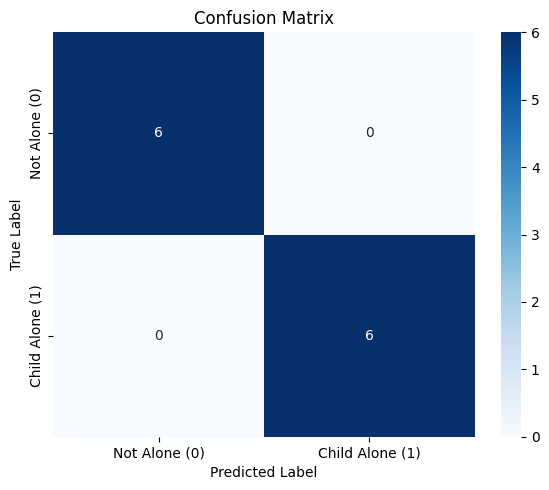

In [ ]:
cm = confusion_matrix(y_true, y_pred)  # [[TN, FP],[FN, TP]]
labels = ["Not Alone (0)", "Child Alone (1)"]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()

# **Machine Learning on CSV**

In [4]:
train_df = pd.read_csv("/content/child_train.csv")
val_df   = pd.read_csv("/content/child_val.csv")
test_df  = pd.read_csv("/content/child_test.csv")


In [5]:
features = [
    "num_children",
    "num_adults",
    "max_alone_time",
    "total_alone_time",
    "adult_presence_ratio"
]

In [6]:
target = "true_label"

X_train = train_df[features]
y_train = train_df[target]

X_val = val_df[features]
y_val = val_df[target]

X_test = test_df[features]
y_test = test_df[target]

In [7]:
# Apply SMOTE
sm = SMOTE(sampling_strategy={1: 100}, random_state=42)
X_sm, y_sm = sm.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_sm).value_counts())

After SMOTE:
true_label
1    100
0     30
Name: count, dtype: int64


In [8]:
# Balance majority class to 100
df_sm = pd.concat([
    pd.DataFrame(X_sm, columns=features),
    pd.Series(y_sm, name=target)
], axis=1)

maj = df_sm[df_sm[target] == 0]
minc = df_sm[df_sm[target] == 1]

maj_up = resample(
    maj,
    replace=True,
    n_samples=100,
    random_state=42
)

min_up = minc

df_bal = pd.concat([maj_up, min_up], ignore_index=True)

X_train_bal = df_bal[features]
y_train_bal = df_bal[target]

print("Final Balanced:")
print(y_train_bal.value_counts())

Final Balanced:
true_label
0    100
1    100
Name: count, dtype: int64


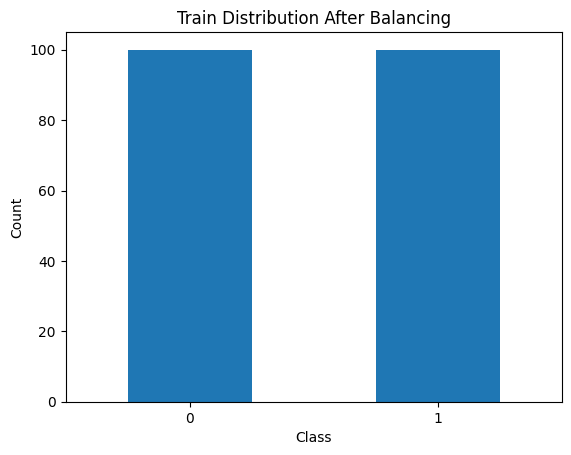

In [9]:
# Plot balanced training distribution
y_train_bal.value_counts().plot(kind="bar")
plt.title("Train Distribution After Balancing")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [10]:
# Scale features
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_bal),
    columns=X_train_bal.columns
)

X_val_scaled = pd.DataFrame(
    scaler.transform(X_val),
    columns=X_val.columns
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)


In [11]:
# Train model

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train_bal)

LogisticRegression(max_iter=1000)

In [12]:
# Validation Prediction
y_val_pred = model.predict(X_val_scaled)

print("===== Validation Results =====")
print("Accuracy :", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred, zero_division=0))
print("Recall   :", recall_score(y_val, y_val_pred, zero_division=0))

===== Validation Results =====
Accuracy : 0.8666666666666667
Precision: 0.75
Recall   : 1.0


In [14]:
# Test Prediction
y_pred = model.predict(X_test_scaled)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)

print("===== Test Results =====")
print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")

===== Test Results =====
Accuracy : 1.000
Precision: 1.000
Recall   : 1.000


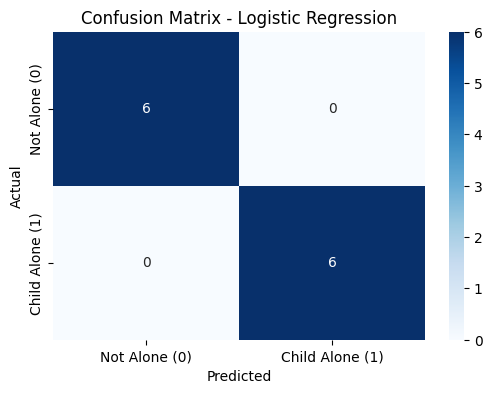

In [15]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

labels = ["Not Alone (0)", "Child Alone (1)"]

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


In [16]:
# Show sample predictions
print(X_test.head())
print(y_pred[:10])

   num_children  num_adults  max_alone_time  total_alone_time  \
0             1           0        3.704316          3.704316   
1             1           0        5.350161          0.728806   
2             1           0       11.112860         11.112860   
3             1           0        6.100586          0.080620   
4             1           0        6.788657          0.012245   

   adult_presence_ratio  
0                   0.0  
1                   0.0  
2                   0.0  
3                   0.0  
4                   0.0  
[1 1 1 1 1 1 0 0 0 0]


In [17]:
joblib.dump(model, "child_detection_model.pkl")

print("Model saved successfully")

Model saved successfully
